In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('CCRB-Complaint-Data_202007271729/allegations_202007271729.csv')
df

,unique_mos_id,first_name,last_name,command_now,shield_no,complaint_id,month_received,year_received,month_closed,year_closed,...,mos_age_incident,complainant_ethnicity,complainant_gender,complainant_age_incident,fado_type,allegation,precinct,contact_reason,outcome_description,board_disposition
0,10004,Jonathan,Ruiz,078 PCT,8409,42835,7,2019,5,2020,...,32,Black,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions)
1,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Discourtesy,Action,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
2,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Offensive Language,Race,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
3,10007,John,Sears,078 PCT,5952,26146,7,2012,9,2013,...,25,Black,Male,45.0,Abuse of Authority,Question,67.0,PD suspected C/V of violation/crime - street,No arrest made or summons issued,Substantiated (Charges)
4,10009,Noemi,Sierra,078 PCT,24058,40253,8,2018,2,2019,...,39,NaN,NaN,16.0,Force,Physical force,67.0,Report-dispute,Arrest - other violation/crime,Substantiated (Command Discipline A)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33353,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,36,Asian,Male,21.0,Discourtesy,Word,66.0,Moving violation,Moving violation summons issued,Unsubstantiated
33354,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,36,Asian,Male,21.0,Abuse of Authority,Interference with recording,66.0,Moving violation,Moving violation summons issued,Unsubstantiated
33355,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,36,Asian,Male,21.0,Abuse of Authority,Search (of person),66.0,Moving violation,Moving violation summons issued,Substantiated (Formalized Training)
33356,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,36,Asian,Male,21.0,Abuse of Authority,Vehicle search,66.0,Moving violation,Moving violation summons issued,Substantiated (Formalized Training)


In [4]:
no_discipline = ['Unsubstantiated', 'Exonerated', 'Unfounded', 'Miscellaneous']

discipline = ['Substantiated (Charges)', 'Substantiated (Command Discipline A)', 
              'Substantiated (Command Discipline)', 'Substantiated (Command Discipline B)',
              'Substantiated (Command Lvl Instructions)', 'Substantiated (Instructions)',
              'Substantiated (Formalized Training)', 'Substantiated (No Recommendations)']

print(no_discipline)
print(discipline)   


['Unsubstantiated', 'Exonerated', 'Unfounded', 'Miscellaneous']
['Substantiated (Charges)', 'Substantiated (Command Discipline A)', 'Substantiated (Command Discipline)', 'Substantiated (Command Discipline B)', 'Substantiated (Command Lvl Instructions)', 'Substantiated (Instructions)', 'Substantiated (Formalized Training)', 'Substantiated (No Recommendations)']


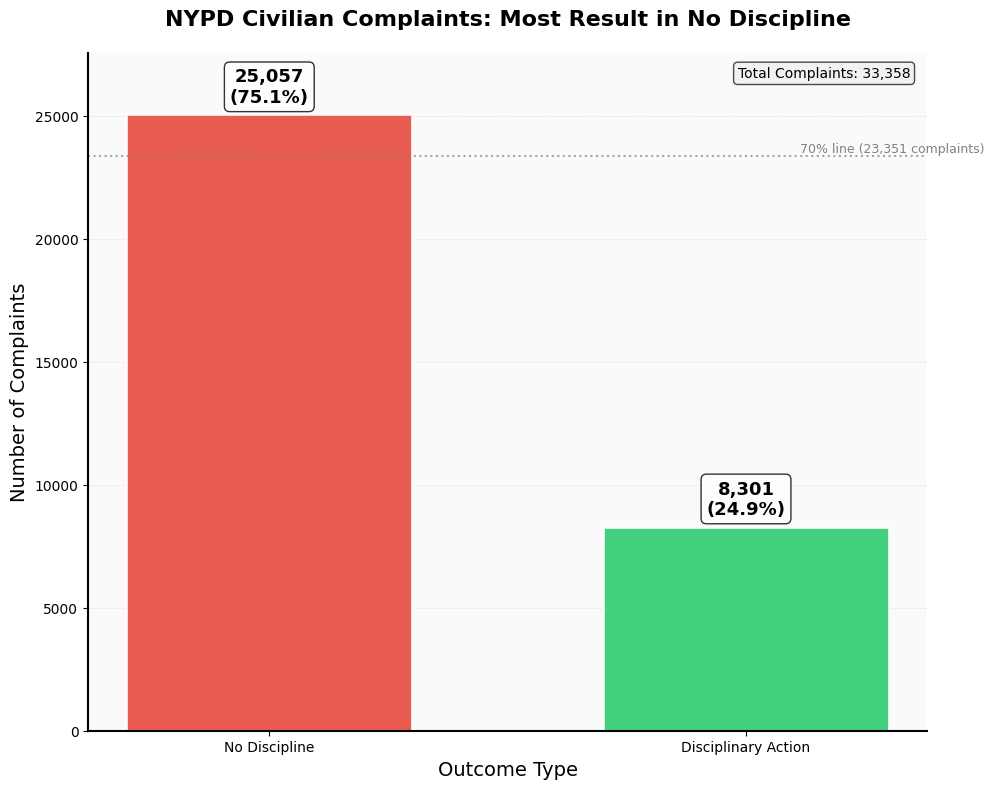

In [ ]:
no_disc_count = df[df['board_disposition'].isin(no_discipline)].shape[0]
discipline_count = len(df) - no_disc_count
total = len(df)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.bar(['No Discipline', 'Disciplinary Action'], 
              [no_disc_count, discipline_count],
              color=['#e74c3c', '#2ecc71'],
              edgecolor='white',
              linewidth=2,
              width=0.6,
              alpha=0.9)

for bar in bars:
    bar.set_zorder(2)

for bar, count in zip(bars, [no_disc_count, discipline_count]):
    pct = count/total*100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (total * 0.01),
            f'{count:,}\n({pct:.1f}%)', 
            ha='center', va='bottom', fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_ylabel('Number of Complaints', fontsize=14, fontweight='medium')
ax.set_xlabel('Outcome Type', fontsize=14, fontweight='medium')
ax.set_title('NYPD Civilian Complaints: Most Result in No Discipline', 
             fontsize=16, fontweight='bold', pad=20)

ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

ax.set_ylim(0, no_disc_count * 1.1)

seventy_percent_mark = total * 0.7
ax.axhline(y=seventy_percent_mark, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(len(bars)-0.5, seventy_percent_mark + (total * 0.005), 
        f'70% line ({seventy_percent_mark:,.0f} complaints)', 
        fontsize=9, color='gray', ha='right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')

ax.text(0.98, 0.98, f'Total Complaints: {total:,}', 
        transform=ax.transAxes, fontsize=10, 
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.7))

plt.tight_layout()
plt.savefig('viz_a1.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()